In [41]:
!pip install shapely
!pip install matplotlib
!pip install numpy
!pip install pandas

In [42]:
import shapely
print(f'Using shapely {shapely.__version__}')

Using shapely 2.1.2


In [43]:
import math
import os
import random
from decimal import Decimal, getcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from shapely import affinity, touches
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.strtree import STRtree
# from multiprocessing import Process, Pool
from concurrent.futures import ThreadPoolExecutor

pd.set_option('display.float_format', '{:.12f}'.format)

# Set precision for Decimal
getcontext().prec = 25
scale_factor = Decimal('1e15')

In [44]:
# Build the index of the submission, in the format:
#  <trees_in_problem>_<tree_index>

index = [f'{n:03d}_{t}' for n in range(1, 201) for t in range(n)]

In [45]:
def generate_weighted_angle():
    """
    Generates a random angle with a distribution weighted by abs(sin(2*angle)).
    This helps place more trees in corners, and makes the packing less round.
    """
    while True:
        angle = random.uniform(0, 2 * math.pi)
        if random.uniform(0, 1) < abs(math.sin(2 * angle)):
            return angle

In [46]:
class ChristmasTree:
    """Represents a single, rotatable Christmas tree of a fixed size."""

    def __init__(self, center_x='0', center_y='0', angle='0'):
        """Initializes the Christmas tree with a specific position and rotation."""
        self.center_x = Decimal(center_x)
        self.center_y = Decimal(center_y)
        self.angle = Decimal(angle)

        trunk_w = Decimal('0.15')
        trunk_h = Decimal('0.2')
        base_w = Decimal('0.7')
        mid_w = Decimal('0.4')
        top_w = Decimal('0.25')
        tip_y = Decimal('0.8')
        tier_1_y = Decimal('0.5')
        tier_2_y = Decimal('0.25')
        base_y = Decimal('0.0')
        trunk_bottom_y = -trunk_h

        initial_polygon = Polygon(
            [
                # Start at Tip
                (Decimal('0.0') * scale_factor, tip_y * scale_factor),
                # Right side - Top Tier
                (top_w / Decimal('2') * scale_factor, tier_1_y * scale_factor),
                (top_w / Decimal('4') * scale_factor, tier_1_y * scale_factor),
                # Right side - Middle Tier
                (mid_w / Decimal('2') * scale_factor, tier_2_y * scale_factor),
                (mid_w / Decimal('4') * scale_factor, tier_2_y * scale_factor),
                # Right side - Bottom Tier
                (base_w / Decimal('2') * scale_factor, base_y * scale_factor),
                # Right Trunk
                (trunk_w / Decimal('2') * scale_factor, base_y * scale_factor),
                (trunk_w / Decimal('2') * scale_factor, trunk_bottom_y * scale_factor),
                # Left Trunk
                (-(trunk_w / Decimal('2')) * scale_factor, trunk_bottom_y * scale_factor),
                (-(trunk_w / Decimal('2')) * scale_factor, base_y * scale_factor),
                # Left side - Bottom Tier
                (-(base_w / Decimal('2')) * scale_factor, base_y * scale_factor),
                # Left side - Middle Tier
                (-(mid_w / Decimal('4')) * scale_factor, tier_2_y * scale_factor),
                (-(mid_w / Decimal('2')) * scale_factor, tier_2_y * scale_factor),
                # Left side - Top Tier
                (-(top_w / Decimal('4')) * scale_factor, tier_1_y * scale_factor),
                (-(top_w / Decimal('2')) * scale_factor, tier_1_y * scale_factor),
            ]
        )
        rotated = affinity.rotate(initial_polygon, float(self.angle), origin=(0, 0))
        self.polygon = affinity.translate(rotated,
                                          xoff=float(self.center_x * scale_factor),
                                          yoff=float(self.center_y * scale_factor))

In [47]:
# Greedy Approach

def initialize_trees_greedy(num_trees, existing_trees=None):
    """
    This builds a simple, greedy starting configuration, by using the previous n-tree
    placements, and adding more tree for the (n+1)-tree configuration. We place a tree
    fairly far away at a (weighted) random angle, and the bring it closer to the center
    until it overlaps. Then we back it up until it no longer overlaps.

    You can easily modify this code to build each n-tree configuration completely
    from scratch.
    """

    # no trees to place, return nothing
    if num_trees == 0:
        return [], Decimal('0')
    # if start from the beginning with no trees, start from nothing. and if there is stuff to start from turn it into a list
    if existing_trees is None:
        placed_trees = []
    else:
        placed_trees = list(existing_trees)
    # how many trees need to place
    num_to_add = num_trees - len(placed_trees)

    if num_to_add > 0:
        # initialize the trees that need to be placed
        unplaced_trees = [
            ChristmasTree(angle=random.uniform(0, 360)) for _ in range(num_to_add)]
        # Only place the first tree at origin if starting from scratch
        if not placed_trees:  
            placed_trees.append(unplaced_trees.pop(0))

        for tree_to_place in unplaced_trees:
            # turn the trees that have been placed into polygons (lowk inefficient to be doing this everytime, change in my thing)
            placed_polygons = [p.polygon for p in placed_trees]
            # helps look for collisions
            tree_index = STRtree(placed_polygons)

            best_px = None
            best_py = None
            min_radius = Decimal('Infinity')

            # This loop tries 10 random starting attempts and keeps the best one
            for _ in range(10):
                # The new tree starts at a position 20 from the center, at a random vector angle.
                angle = generate_weighted_angle()
                vx = Decimal(str(math.cos(angle)))
                vy = Decimal(str(math.sin(angle)))

                # Move towards center along the vector in steps of 0.5 until collision
                radius = Decimal('20.0')
                step_in = Decimal('0.5')

                collision_found = False
                while radius >= 0:
                    # position to check
                    px = radius * vx
                    py = radius * vy
                    # creates the polygon to check
                    candidate_poly = affinity.translate(
                        tree_to_place.polygon,
                        xoff=float(px * scale_factor),
                        yoff=float(py * scale_factor))

                    # Looking for nearby objects
                    possible_indices = tree_index.query(candidate_poly)
                    # This is the collision detection step
                    if any((candidate_poly.intersects(placed_polygons[i]) and not
                            candidate_poly.touches(placed_polygons[i]))
                           for i in possible_indices):
                        collision_found = True
                        break
                    # step closer if no collision found
                    radius -= step_in

                # back up in steps of 0.05 until it no longer has a collision.
                if collision_found:
                    step_out = Decimal('0.05')
                    while True:
                        radius += step_out
                        px = radius * vx
                        py = radius * vy

                        candidate_poly = affinity.translate(
                            tree_to_place.polygon,
                            xoff=float(px * scale_factor),
                            yoff=float(py * scale_factor))

                        possible_indices = tree_index.query(candidate_poly)
                        if not any((candidate_poly.intersects(placed_polygons[i]) and not
                                   candidate_poly.touches(placed_polygons[i]))
                                   for i in possible_indices):
                            break
                # No collision found even at the center. Place it at the center.
                else:
                    radius = Decimal('0')
                    px = Decimal('0')
                    py = Decimal('0')
                # if the radius is better than the previous guesses/iterations, it's a better score so update
                if radius < min_radius:
                    min_radius = radius
                    best_px = px
                    best_py = py
            # update the tree to place's info based on the greedy search
            tree_to_place.center_x = best_px
            tree_to_place.center_y = best_py
            tree_to_place.polygon = affinity.translate(
                tree_to_place.polygon,
                xoff=float(tree_to_place.center_x * scale_factor),
                yoff=float(tree_to_place.center_y * scale_factor),
            )
            placed_trees.append(tree_to_place)  # Add the newly placed tree to the list
    # gets the polygons for all placed trees, including those which have been put down by the algo and gets the bounds
    all_polygons = [t.polygon for t in placed_trees]
    bounds = unary_union(all_polygons).bounds

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny
    # this forces a square bounding using the largest side
    side_length = max(width, height)
    # calculates the score of the frame based on the stigma
    score = side_length * side_length / num_trees

    return placed_trees, side_length, score

In [48]:
def plot_results(side_length, placed_trees, num_trees, score):
    """Plots the arrangement of trees and the bounding square."""
    _, ax = plt.subplots(figsize=(6, 6))
    colors = plt.cm.viridis([i / num_trees for i in range(num_trees)])

    all_polygons = [t.polygon for t in placed_trees]
    bounds = unary_union(all_polygons).bounds

    for i, tree in enumerate(placed_trees):
        # Rescale for plotting
        x_scaled, y_scaled = tree.polygon.exterior.xy
        x = [Decimal(val) / scale_factor for val in x_scaled]
        y = [Decimal(val) / scale_factor for val in y_scaled]
        ax.plot(x, y, color=colors[i])
        ax.fill(x, y, alpha=0.5, color=colors[i])

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny

    square_x = minx if width >= height else minx - (side_length - width) / 2
    square_y = miny if height >= width else miny - (side_length - height) / 2
    bounding_square = Rectangle(
        (float(square_x), float(square_y)),
        float(side_length),
        float(side_length),
        fill=False,
        edgecolor='red',
        linewidth=2,
        linestyle='--',
    )
    ax.add_patch(bounding_square)

    padding = 0.5
    ax.set_xlim(
        float(square_x - Decimal(str(padding))),
        float(square_x + side_length + Decimal(str(padding))))
    ax.set_ylim(float(square_y - Decimal(str(padding))),
                float(square_y + side_length + Decimal(str(padding))))
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
    plt.title(f'{num_trees} Trees: {side_length:.12f} Score: {score: .12f}')
    plt.show()
    plt.close()

In [ ]:
# Simulated Annealing Approach
executor = ThreadPoolExecutor(max_workers=8)

def calculateScore(polygons):
    bounds = unary_union(polygons).bounds

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny
    # this forces a square bounding using the largest side
    side_length = max(width, height)

    # calculate potential score of each
    score = side_length * side_length / len(polygons)

    return (side_length, score)

def checkPotentialTree(args):
    candidate_poly, placed_polygons, tree_index = args

    possible_indices = tree_index.query(candidate_poly)

    temp = placed_polygons + [candidate_poly]

    global_bbox = unary_union(placed_polygons).envelope
    
    if not candidate_poly.envelope.intersects(global_bbox):
        _, score = calculateScore(temp)
        return score

    if any(
        candidate_poly.intersects(placed_polygons[i]) and
        not candidate_poly.touches(placed_polygons[i])
        for i in possible_indices
    ):
        return Decimal('Infinity')
    
    _, score = calculateScore(temp)
    return score

def make_polygon(base_poly, x, y, angle):
    poly = affinity.translate(
        base_poly,
        xoff=float(x * scale_factor),
        yoff=float(y * scale_factor)
    )
    return affinity.rotate(poly, float(angle))

def generate_candidates(x, y, angle, temperature, k=8):
    candidates = []
    for _ in range(k):
        r = 5 * temperature
        angleR = 90 * temperature

        px = x + Decimal(random.uniform(-r, r))
        py = y + Decimal(random.uniform(-r, r))
        pangle = angle + Decimal(random.uniform(-angleR, angleR))

        tree = ChristmasTree().polygon
        tree = make_polygon(tree, px, py, pangle)

        candidates.append((tree, px, py, pangle))

    return candidates


def initialize_trees_simulated_aneealing(num_trees, existing_trees=None):
    """
    Will be like DP where it relies on previous iterations and will use simulated annealing to place each new tree
    """
    # none trees to place, return nothing
    if num_trees == 0:
        return [], Decimal('0')
    # start from beginnning or create list of already placed trees
    if existing_trees is None:
        placed_trees = []
    else:
        placed_trees = list(existing_trees)
    # number of trees to place
    num_to_add = num_trees - len(placed_trees)
    for i in range(num_to_add):
        placed_polygons = [p.polygon for p in placed_trees]
        tree_index = STRtree(placed_polygons)
        best_score = Decimal('Infinity')

        # The new tree starts at a position 20 from the center, at a random vector angle. This is ok, random arbitray high temperature
        angle = generate_weighted_angle()
        x = Decimal(str(math.cos(angle))) * 20
        y = Decimal(str(math.sin(angle))) * 20
        angle = 0

        maxIterations = 250
        # need to change the loop, doesn't matter right now
        while(best_score == Decimal('Infinity')):
            for i in range(maxIterations):

                temperature = 1 - i / maxIterations
                score = 0

                candidates = generate_candidates(x, y, angle, temperature, k=8)

                jobs = [(tree, placed_polygons, tree_index) for tree, _, _, _ in candidates]

                scores = list(executor.map(checkPotentialTree, jobs))
                
                print("Scores: {0}".format(scores))

                best_idx = min(range(len(scores)), key=lambda i: scores[i])

                score = scores[best_idx]
                _, px, py, pangle = candidates[best_idx]

                if(score < best_score):
                    best_score = score
                    x = px
                    y = py
                    angle = pangle
                    print("Best Score Updated: {0}.".format(best_score))
        tree_to_place = ChristmasTree()
        tree_to_place.center_x = x
        tree_to_place.center_y = y
        tree_to_place.angle = angle
        tree_to_place.polygon = affinity.translate(
            tree_to_place.polygon,
            xoff=float(tree_to_place.center_x * scale_factor),
            yoff=float(tree_to_place.center_y * scale_factor),
        )
        tree_to_place.polygon = affinity.rotate(tree_to_place.polygon, float(angle))
        placed_trees.append(tree_to_place)  # Add the newly placed tree to the list

    all_polygons = [t.polygon for t in placed_trees]
    side_length, score = calculateScore(all_polygons)

    return placed_trees, side_length, score

Scores: [Decimal('0.8458474219367694003872005371'), Decimal('0.9520014879992704683272221025'), Decimal('0.8649315930622354498125447773'), Decimal('0.9582034300491220342353499546'), Decimal('0.9692923080866661986402174318'), Decimal('0.8662012526166171959438333357'), Decimal('1.004704906900755527720193617'), Decimal('1.000278228351462114996300490')]
Best Score Updated: 0.8458474219367694003872005371.
Scores: [Decimal('0.8057127286165409208615603994'), Decimal('0.6759781823293960566994772718'), Decimal('0.7115992958303126361167920497'), Decimal('0.9737766518169453880278767405'), Decimal('0.9863496445851358442304193486'), Decimal('0.9907006869785260278976046884'), Decimal('0.9918500763160276138788443876'), Decimal('0.9964091394823710434903270464')]
Best Score Updated: 0.6759781823293960566994772718.
Scores: [Decimal('0.7365590769081678765788658529'), Decimal('0.6702868871206887429058245919'), Decimal('1.005486043112079642564824090'), Decimal('0.6910726237140574181558996629'), Decimal('0.6

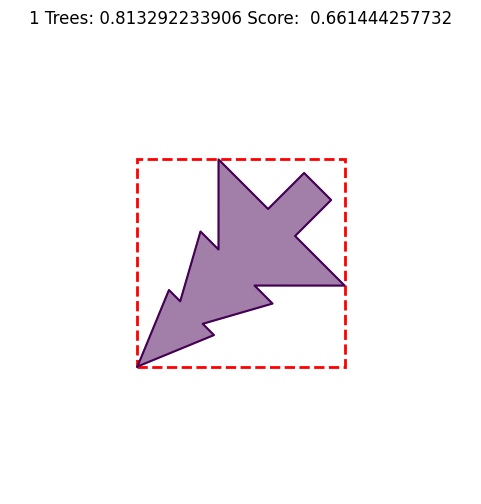

Scores: [Decimal('1012.133761082394804417854915'), Decimal('915.9338116869504903929327255'), Decimal('743.131826020084836430707539'), Decimal('771.8151793206179380037864265'), Decimal('903.8204442151858381472787885'), Decimal('976.315498980064690736060070'), Decimal('735.7072489459269503882933065'), Decimal('991.9979785840659159516145915')]
Best Score Updated: 735.7072489459269503882933065.
Scores: [Decimal('741.621095728744767612338401'), Decimal('634.006176316173280652636776'), Decimal('581.833151241621363682615682'), Decimal('714.120402013405575561103884'), Decimal('845.579973526656506357607371'), Decimal('812.4389599586233025560359375'), Decimal('929.216066309668211227712287'), Decimal('828.5399971276787011762767975')]
Best Score Updated: 581.833151241621363682615682.
Scores: [Decimal('614.0965962279416629862857705'), Decimal('686.681042935281007638524735'), Decimal('430.4191608699383845126676988'), Decimal('703.5177306086082787724314665'), Decimal('499.9021675713583219180473966'),

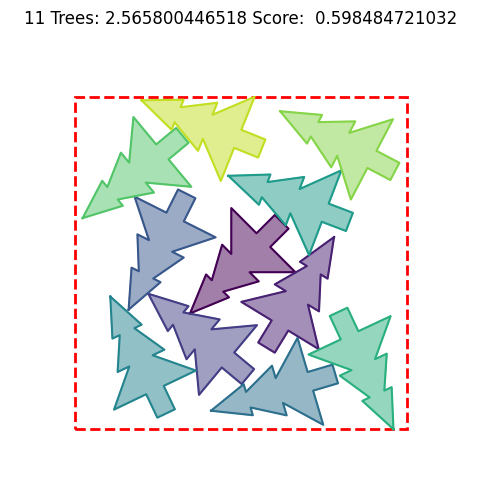

Scores: [Decimal('21.10061920916662191025222778'), Decimal('21.99000477801598616501365627'), Decimal('24.76457938799065024022021688'), Decimal('25.63526666467474851725216514'), Decimal('12.95163028868892014466023187'), Decimal('21.98618532708559503920464096'), Decimal('33.37697548677789847176980205'), Decimal('37.99987638553024390301112581')]
Best Score Updated: 12.95163028868892014466023187.
Scores: [Decimal('20.2557824446098957962508125'), Decimal('17.72569786850292122997296651'), Decimal('4.847971570707122168368925972'), Decimal('12.64402434041086481426981936'), Decimal('20.48238877836599295155029186'), Decimal('8.579574462252870504899085942'), Decimal('8.63851306570462489333398195'), Decimal('23.20833186051240295345327342')]
Best Score Updated: 4.847971570707122168368925972.
Scores: [Decimal('5.923386077679336952572130822'), Decimal('2.942760309761006838748531001'), Decimal('7.239454951397306314461906469'), Decimal('9.484371830003623138451092633'), Decimal('10.035041078173230119750

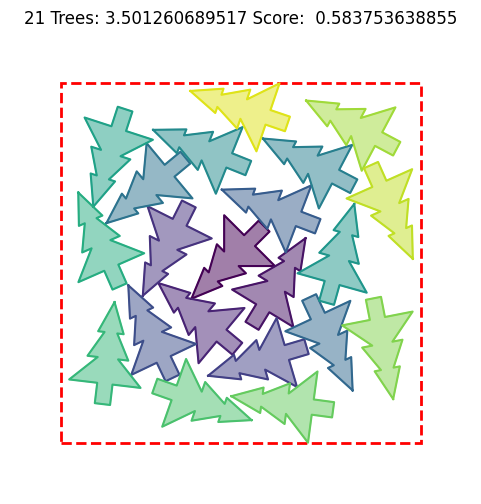

Scores: [Decimal('84.80406342759917042257546755'), Decimal('68.80128057556606419062383786'), Decimal('72.80794060072263283283190055'), Decimal('100.1644755737817834260238404'), Decimal('87.92316954817264282469182514'), Decimal('106.2174485287633856280444417'), Decimal('70.57767977898930250913018682'), Decimal('89.58182829000205087611194482')]
Best Score Updated: 68.80128057556606419062383786.
Scores: [Decimal('76.31657388332065383763618655'), Decimal('84.85280946371469537548412014'), Decimal('70.15738440194557132582328655'), Decimal('76.10260135392536487663140177'), Decimal('63.28846160672560475080474377'), Decimal('86.88753042318736167548388491'), Decimal('72.79397280101564844135132227'), Decimal('83.56478445302354715721729891')]
Best Score Updated: 63.28846160672560475080474377.
Scores: [Decimal('50.95209731657480629791405918'), Decimal('68.93601845996627427209254082'), Decimal('57.66908417003408187040918195'), Decimal('52.73743961157309725706858655'), Decimal('61.6084198743391047535

KeyboardInterrupt: 

In [50]:
tree_data = []
current_placed_trees = []  # Initialize an empty list for the first iteration
total_score = 0
for n in range(200):
    # Pass the current_placed_trees to initialize_trees
    current_placed_trees, side, score = initialize_trees_simulated_aneealing(n+1, existing_trees=current_placed_trees)
    total_score = total_score + score
    if (n%10 == 0):
        plot_results(side, current_placed_trees, n+1, score)
    for tree in current_placed_trees:
        tree_data.append([tree.center_x, tree.center_y, tree.angle])
        
cols = ['x', 'y', 'deg']
submission = pd.DataFrame(
    index=index, columns=cols, data=tree_data).rename_axis('id')

for col in cols:
    submission[col] = submission[col].astype(float).round(decimals=6)
    
# To ensure everything is kept as a string, prepend an 's'
for col in submission.columns:
    submission[col] = 's' + submission[col].astype('string')
submission.to_csv('sample_submission.csv')

print(total_score)